# Predicting hotel ranking from booking.com

In [1]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
import category_encoders as ce
import matplotlib.pyplot as plt
import seaborn as sns

## Descriptive data analysis

In [2]:
hotels = pd.read_csv('data/hotels.csv')
hotels.head()

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,tags,days_since_review,lat,lng
0,Stratton Street Mayfair Westminster Borough Lo...,581,2/19/2016,8.4,The May Fair Hotel,United Kingdom,Leaving,3,1994,Staff were amazing,4,7,10.0,"[' Leisure trip ', ' Couple ', ' Studio Suite ...",531 day,51.507894,-0.143671
1,130 134 Southampton Row Camden London WC1B 5AF...,299,1/12/2017,8.3,Mercure London Bloomsbury Hotel,United Kingdom,poor breakfast,3,1361,location,2,14,6.3,"[' Business trip ', ' Couple ', ' Standard Dou...",203 day,51.521009,-0.123097
2,151 bis Rue de Rennes 6th arr 75006 Paris France,32,10/18/2016,8.9,Legend Saint Germain by Elegancia,China,No kettle in room,6,406,No Positive,0,14,7.5,"[' Leisure trip ', ' Solo traveler ', ' Modern...",289 day,48.845377,2.325643
3,216 Avenue Jean Jaures 19th arr 75019 Paris Fr...,34,9/22/2015,7.5,Mercure Paris 19 Philharmonie La Villette,United Kingdom,No Negative,0,607,Friendly staff quiet comfortable room spotles...,11,8,10.0,"[' Leisure trip ', ' Solo traveler ', ' Standa...",681 day,48.888697,2.394540
4,Molenwerf 1 1014 AG Amsterdam Netherlands,914,3/5/2016,8.5,Golden Tulip Amsterdam West,Poland,Torn sheets,4,7586,The staff was very friendly and helpful Break...,20,10,9.6,"[' Business trip ', ' Couple ', ' Standard Dou...",516 day,52.385601,4.847060


In [3]:
hotels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 386803 entries, 0 to 386802
Data columns (total 17 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               386803 non-null  object 
 1   additional_number_of_scoring                386803 non-null  int64  
 2   review_date                                 386803 non-null  object 
 3   average_score                               386803 non-null  float64
 4   hotel_name                                  386803 non-null  object 
 5   reviewer_nationality                        386803 non-null  object 
 6   negative_review                             386803 non-null  object 
 7   review_total_negative_word_counts           386803 non-null  int64  
 8   total_number_of_reviews                     386803 non-null  int64  
 9   positive_review                             386803 non-null  object 
 

386803 missing values in dataset (columns lat and lng).

Lets check for duplicates:

In [4]:
# Удаляем дубликаты:
hotels = hotels.drop_duplicates()
hotels.shape[0]

386496

## Feature engeneering

Starting with tags.

In [5]:
hotels['tags'] = hotels['tags'].apply(eval)

I used the most important tags in my opinion.

In [6]:
hotels['Leisure_trip']= hotels['tags'].apply(lambda tags: int(any('Leisure trip' in tag for tag in tags)))
hotels['Couple']= hotels['tags'].apply(lambda tags: int(any('Couple' in tag for tag in tags)))
hotels['Stayed_1_night']= hotels['tags'].apply(lambda tags: int(any('Stayed 1 night' in tag for tag in tags)))
hotels['Business_trip']= hotels['tags'].apply(lambda tags: int(any('Business trip' in tag for tag in tags)))
hotels['Solo_traveler']= hotels['tags'].apply(lambda tags: int(any('Solo traveler' in tag for tag in tags)))

In [7]:
hotels['Leisure_trip'].value_counts()

Leisure_trip
1    313353
0     73143
Name: count, dtype: int64

Adding quantity of tags as a feature. 

In [8]:
hotels['tag_count']= hotels['tags'].apply(lambda x: len(x))

Manualy encoding positive and negative reviews.

In [9]:
hotels['negative_review']= hotels['negative_review'].apply(lambda x: 0 if x== 'No Negative' else 1)
hotels['positive_review']= hotels['positive_review'].apply(lambda x: 0 if x== 'No Positive' else 1)

Geting months and quarters, Adjusting days since review.

In [10]:
# Преобразовываем дату и добываем месяцы (можо попробовать получить и сезоны).
hotels['review_date'] = pd.to_datetime(hotels['review_date'])
hotels['review_date_m']= hotels['review_date'].dt.month
hotels['review_date_qt']= hotels['review_date'].dt.quarter

# Получаем числовой признак дней с момента публикации отзыва.
def get_days(text):
    text= text.split()
    return text[0]

hotels['days_since_review']= hotels['days_since_review'].apply(get_days)

Scaling features using RobustScaler, becouse there could be annomalies.

In [11]:

hotels_num= ['total_number_of_reviews', 'review_total_negative_word_counts', 'review_total_positive_word_counts', 'total_number_of_reviews_reviewer_has_given', 'additional_number_of_scoring', 'days_since_review', 'tag_count']
r_scaler=  preprocessing.RobustScaler()
hotels[hotels_num]= r_scaler.fit_transform(hotels[hotels_num])

Trying to get city names without geopy.

In [ ]:
def get_city(text):
     text=text.split()
     if text[-2] == 'United':
         return text[-5]
     else:
         return text[-2]
    
hotels['city']= hotels['hotel_address'].apply(get_city)
hotels['city'].value_counts()

city
London       196773
Barcelona     45132
Paris         44528
Amsterdam     43004
Vienna        29177
Milan         27882
Name: count, dtype: int64

Ended up with 6 cities. 

OrdinalEncoder.

In [ ]:
ord_encoder = ce.OrdinalEncoder(mapping=[{
	'col': 'city',
	'mapping': {'London': 1, 'Barcelona': 2, 'Paris': 3, 
                'Amsterdam': 4, 'Vienna': 5, 'Milan': 6}
}])
data_bin = ord_encoder.fit_transform(hotels[['city']])

hotels['city']= data_bin

Not to lose reviewer nationality I used BinaryEncoder.

In [14]:
bin_encoder = ce.BinaryEncoder(cols=['reviewer_nationality']) 
type_bin = bin_encoder.fit_transform(hotels['reviewer_nationality'])
hotels = pd.concat([hotels, type_bin], axis=1)

In [15]:
bin_encoder = ce.BinaryEncoder(cols=['hotel_name']) 
type_bin = bin_encoder.fit_transform(hotels['hotel_name'])
hotels = pd.concat([hotels, type_bin], axis=1)

Droping original columns.

In [19]:
hotels= hotels.drop(['hotel_address', 'review_date', 'hotel_name', 'reviewer_nationality', 'tags', 'lat', 'lng'], axis=1)

## Multicollinearity analysis

<Axes: >

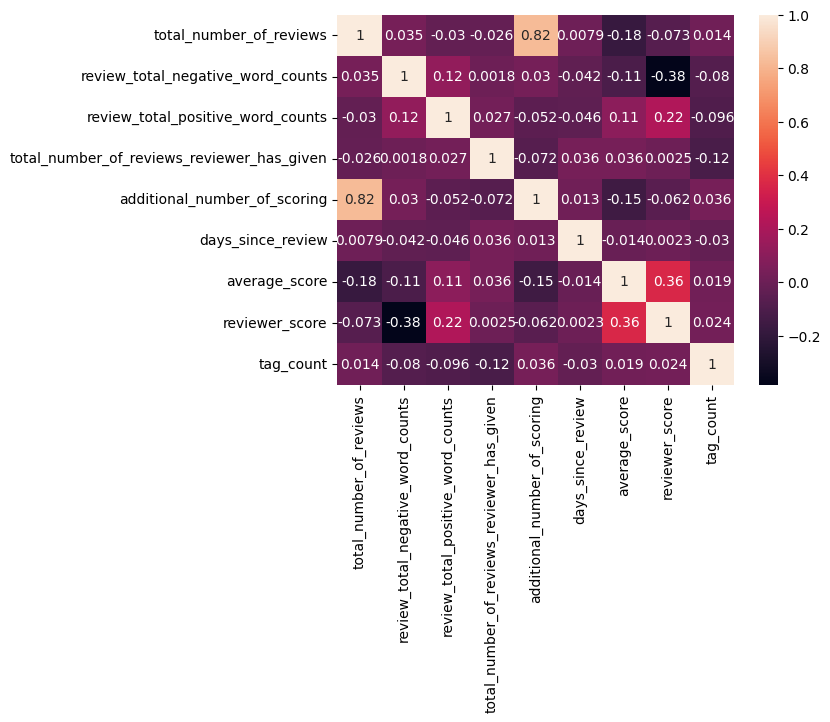

In [20]:
num= hotels[['total_number_of_reviews', 'review_total_negative_word_counts', 'review_total_positive_word_counts', 'total_number_of_reviews_reviewer_has_given', 'additional_number_of_scoring', 'days_since_review', 'average_score', 'reviewer_score', 'tag_count']]
sns.heatmap(num.corr(), annot=True)

Droping correlated columns.

In [ ]:
hotels= hotels.drop(['additional_number_of_scoring'],axis=1)

In [ ]:
num_cols = ['total_number_of_reviews', 'review_total_negative_word_counts', 'review_total_positive_word_counts', 'total_number_of_reviews_reviewer_has_given', 'days_since_review', 'tag_count']
cat_cols = ['average_score', 'Leisure_trip', 'Couple', 'Stayed_1_night',
       'Business_trip', 'Solo_traveler', 'review_date_m', 'review_date_qt', 'city',
       'reviewer_nationality_0', 'reviewer_nationality_1',
       'reviewer_nationality_2', 'reviewer_nationality_3',
       'reviewer_nationality_4', 'reviewer_nationality_5',
       'reviewer_nationality_6', 'reviewer_nationality_7', 'hotel_name_0',
       'hotel_name_1', 'hotel_name_2', 'hotel_name_3', 'hotel_name_4',
       'hotel_name_5', 'hotel_name_6', 'hotel_name_7', 'hotel_name_8',
       'hotel_name_9', 'hotel_name_10', 'positive_review', 'negative_review']

In [ ]:
 
X = hotels.drop(['reviewer_score'], axis = 1)  
y = hotels['reviewer_score'] 

<Axes: >

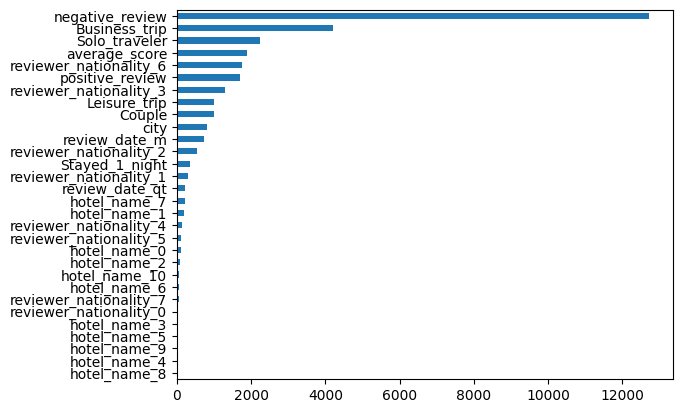

In [ ]:
y=y.astype('int')

...
from sklearn.feature_selection import chi2 

imp_cat = pd.Series(chi2(X[cat_cols], y)[0], index=cat_cols)
imp_cat.sort_values(inplace = True)
imp_cat.plot(kind = 'barh')

<Axes: >

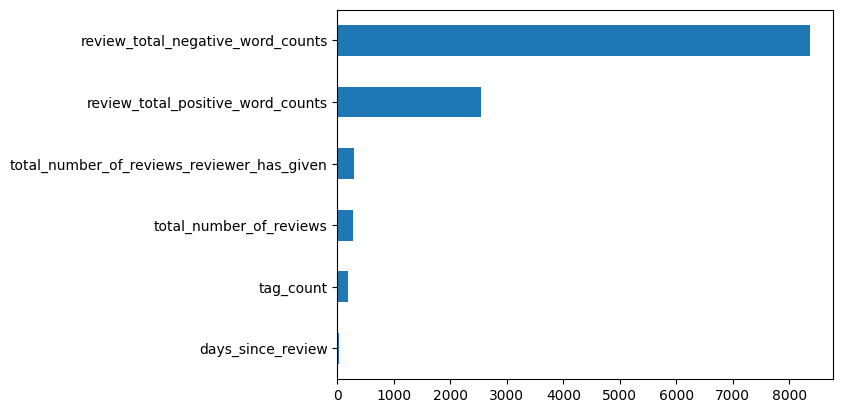

In [24]:
from sklearn.feature_selection import f_classif # anova

imp_num = pd.Series(f_classif(X[num_cols], y)[0], index = num_cols)
imp_num.sort_values(inplace = True)
imp_num.plot(kind = 'barh')

In [25]:
X= X.drop(['hotel_name_8', 'hotel_name_4', 'hotel_name_9', 'hotel_name_5', 'hotel_name_3', 'reviewer_nationality_0', 'reviewer_nationality_7', 'hotel_name_6', 'hotel_name_10', 'days_since_review'], axis=1)

In [ ]:
from sklearn.model_selection import train_test_split  

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestRegressor # инструмент для создания и обучения модели  
from sklearn import metrics # инструменты для оценки точности модели  
  
  
regr = RandomForestRegressor(n_estimators=100)  
      
regr.fit(X_train, y_train)  
      
y_pred = regr.predict(X_test)  


In [ ]:
print('MAPE:', metrics.mean_absolute_percentage_error(y_test, y_pred))

MAPE: 0.1610473361532944
